S&P

In [ ]:
import yfinance as yf
import pandas as pd

# Choose a stock ticker symbol
ticker_symbol = '^GSPC'

# Get the stock data
GSPC = yf.download(ticker_symbol, start='1927-12-31', end='2023-01-01')
GSPC.reset_index(inplace=True)
GSPC.rename(columns={'Date': 'DATE'}, inplace=True)

# Save to CSV
GSPC.to_csv(f'{ticker_symbol}_data.csv')

[*********************100%%**********************]  1 of 1 completed


In [ ]:
nan_percentages = (GSPC.isnull().mean() * 100).round(2)

# Create a DataFrame to display NaN percentages
nan_percentages_df = pd.DataFrame({'Column': nan_percentages.index, 'NaN Percentage': nan_percentages.values})

# Display all rows of nan_percentages_df
with pd.option_context('display.max_rows', None):
    print("Percentage of NaN values in each column:")
    print(nan_percentages_df)

Percentage of NaN values in each column:
      Column  NaN Percentage
0       DATE             0.0
1       OPEN             0.0
2       HIGH             0.0
3        LOW             0.0
4      CLOSE             0.0
5  ADJ CLOSE             0.0
6     VOLUME             0.0


In [ ]:
GSPC.head()

,DATE,Open,High,Low,Close,Adj Close,Volume
0,1928-01-03,17.760000,17.760000,17.760000,17.760000,17.760000,0
1,1928-01-04,17.719999,17.719999,17.719999,17.719999,17.719999,0
2,1928-01-05,17.549999,17.549999,17.549999,17.549999,17.549999,0
3,1928-01-06,17.660000,17.660000,17.660000,17.660000,17.660000,0
4,1928-01-09,17.500000,17.500000,17.500000,17.500000,17.500000,0


In [ ]:
GSPC.shape

(23864, 6)

Urban CPI

In [ ]:
!pip install pandas openpyxl

In [ ]:
import pandas as pd

# Step 1: Read the .xlsx file, skipping the first 10 rows
df = pd.read_excel('/content/SeriesReport-20240716133347_274c6a.xlsx', skiprows=10)

df.columns = df.iloc[0]  # Set the first row as the header
df = df[1:]  # Remove the first row

# Reset the index to be sequential
df.reset_index(drop=True, inplace=True)

df.to_csv('cleaned_file.csv', index=False)
# Step 3: Read the cleaned .csv file into a DataFrame
Urban_CPI = pd.read_csv('cleaned_file.csv')

Urban_CPI.head()

/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,HALF1,HALF2
0,1913,9.8,9.8,9.8,9.8,9.7,9.8,9.9,9.9,10.0,10.0,10.1,10.0,NaN,NaN
1,1914,10.0,9.9,9.9,9.8,9.9,9.9,10.0,10.2,10.2,10.1,10.2,10.1,NaN,NaN
2,1915,10.1,10.0,9.9,10.0,10.1,10.1,10.1,10.1,10.1,10.2,10.3,10.3,NaN,NaN
3,1916,10.4,10.4,10.5,10.6,10.7,10.8,10.8,10.9,11.1,11.3,11.5,11.6,NaN,NaN
4,1917,11.7,12.0,12.0,12.6,12.8,13.0,12.8,13.0,13.3,13.5,13.5,13.7,NaN,NaN


In [ ]:
Urban_CPI['HALF1'].isna().sum()

71

In [ ]:
Urban_CPI['HALF2'].isna().sum()

72

In [ ]:
# Dropping the 'HALF1' and 'HALF2' columns
Urban_CPI = Urban_CPI.drop(columns=['HALF1', 'HALF2'])

# Melt the DataFrame to combine the month and year columns
Urban_CPI_melted = Urban_CPI.melt(id_vars='Year', var_name='Month', value_name='CPI')

# Create the 'date' column by combining 'Year' and 'Month'
Urban_CPI_melted['DATE'] = pd.to_datetime(Urban_CPI_melted['Year'].astype(str) + '-' + Urban_CPI_melted['Month'], format='%Y-%b')

# Drop the 'Year' and 'Month' columns as they are no longer needed
Urban_CPI_cleaned = Urban_CPI_melted.drop(columns=['Year', 'Month'])

# Sort the DataFrame by 'date'
Urban_CPI_cleaned = Urban_CPI_cleaned.sort_values('DATE').reset_index(drop=True)

# Display the cleaned DataFrame
print(Urban_CPI_cleaned)

      CPI       DATE
0     9.8 1913-01-01
1     9.8 1913-02-01
2     9.8 1913-03-01
3     9.8 1913-04-01
4     9.7 1913-05-01
...   ...        ...
1339  NaN 2024-08-01
1340  NaN 2024-09-01
1341  NaN 2024-10-01
1342  NaN 2024-11-01
1343  NaN 2024-12-01

[1344 rows x 2 columns]


PPIACO

In [ ]:
df_PPI = pd.read_csv('/content/PPIACO.csv')
df_PPI.head()

,DATE,PPIACO
0,1913-01-01,12.1
1,1913-02-01,12.0
2,1913-03-01,12.0
3,1913-04-01,12.0
4,1913-05-01,11.9


GDP

In [ ]:
df_GDP = pd.read_csv('/content/GDP.csv')
df_GDP.head()

,DATE,GDP
0,1947-01-01,243.164
1,1947-04-01,245.968
2,1947-07-01,249.585
3,1947-10-01,259.745
4,1948-01-01,265.742


FedFunds

In [ ]:
df_FF = pd.read_csv('/content/FEDFUNDS.csv')
df_FF.head()

,DATE,FEDFUNDS
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83


PAYEMS

In [ ]:
df_Payems = pd.read_csv('/content/PAYEMS.csv')
df_Payems.head()

,DATE,PAYEMS
0,1939-01-01,29923
1,1939-02-01,30100
2,1939-03-01,30280
3,1939-04-01,30094
4,1939-05-01,30299


PE Ratio

In [ ]:
df_PER = pd.read_csv('/content/sp-500-pe-ratio-price-to-earnings-chart.csv', header=8)
# Set header to line 15 (zero-indexed) so line 16 is treated as column names

df_PER.head()

,date,value
0,1927-12-01,15.9099
1,1928-01-01,14.8898
2,1928-02-01,14.6271
3,1928-03-01,16.3390
4,1928-04-01,15.8000


In [ ]:
columns = df_PER.columns.tolist()
columns

['DATE', ' value']

In [ ]:
# Rename the columns
df_PER.rename(columns={'date': 'DATE', ' value': 'PER'}, inplace=True)

# Display the DataFrame after renaming

In [ ]:
df_PER.head()

,DATE,PER
0,1927-12-01,15.9099
1,1928-01-01,14.8898
2,1928-02-01,14.6271
3,1928-03-01,16.3390
4,1928-04-01,15.8000


In [ ]:
# Check column names
print("Column names in Urban_CPI:", Urban_CPI.columns)

Column names in Urban_CPI: Index(['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
       'OCT', 'NOV', 'DEC'],
      dtype='object')


In [ ]:
# Clean column names
datasets = [GSPC, Urban_CPI_cleaned, df_PPI, df_GDP, df_FF, df_Payems, df_PER]
for df in datasets:
    df.columns = df.columns.str.strip().str.upper()  # Strip whitespace and convert to uppercase

# Create a DataFrame with daily dates from 1954-07-01 to the max date in your datasets
start_date = '1954-07-01'
end_date = '2023-01-01'
all_dates = pd.DataFrame({'DATE': pd.date_range(start=start_date, end=end_date, freq='D')})

def forward_fill(df, date_col='DATE'):
    # Ensure the DATE column is a datetime type
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).resample('D').ffill().reset_index()
    return df


# Forward fill monthly and quarterly datasets
Urban_CPI_ff = forward_fill(Urban_CPI_cleaned)
df_PPI_ff = forward_fill(df_PPI)
df_GDP_ff = forward_fill(df_GDP)
df_FF_ff = forward_fill(df_FF)
df_Payem_ff = forward_fill(df_Payems)
df_PER_ff = forward_fill(df_PER)

# Merge all datasets on the 'DATE' column
merged_df = all_dates.merge(GSPC, on='DATE', how='left')
merged_df = merged_df.merge(Urban_CPI_ff, on='DATE', how='left')
merged_df = merged_df.merge(df_PPI_ff, on='DATE', how='left')
merged_df = merged_df.merge(df_GDP_ff, on='DATE', how='left')
merged_df = merged_df.merge(df_FF_ff, on='DATE', how='left')
merged_df = merged_df.merge(df_Payem_ff, on='DATE', how='left')
merged_df = merged_df.merge(df_PER_ff, on='DATE', how='left')

# Display the merged DataFrame
print(merged_df.head())

# Optionally, save to a CSV file
merged_df.to_csv('combined_dataset.csv', index=False)

        DATE       OPEN       HIGH        LOW      CLOSE  ADJ CLOSE  \
0 1954-07-01  29.209999  29.209999  29.209999  29.209999  29.209999   
1 1954-07-02  29.590000  29.590000  29.590000  29.590000  29.590000   
2 1954-07-03        NaN        NaN        NaN        NaN        NaN   
3 1954-07-04        NaN        NaN        NaN        NaN        NaN   
4 1954-07-05        NaN        NaN        NaN        NaN        NaN   

      VOLUME   CPI  PPIACO      GDP  FEDFUNDS  PAYEMS      PER  
0  1860000.0  26.9    29.3  390.996       0.8   48835  11.7414  
1  1980000.0  26.9    29.3  390.996       0.8   48835  11.7414  
2        NaN  26.9    29.3  390.996       0.8   48835  11.7414  
3        NaN  26.9    29.3  390.996       0.8   48835  11.7414  
4        NaN  26.9    29.3  390.996       0.8   48835  11.7414  


In [ ]:
merged_df.head()

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME,CPI,PPIACO,GDP,FEDFUNDS,PAYEMS,PER
0,1954-07-01,29.209999,29.209999,29.209999,29.209999,29.209999,1860000.0,26.9,29.3,390.996,0.8,48835,11.7414
1,1954-07-02,29.590000,29.590000,29.590000,29.590000,29.590000,1980000.0,26.9,29.3,390.996,0.8,48835,11.7414
2,1954-07-03,NaN,NaN,NaN,NaN,NaN,NaN,26.9,29.3,390.996,0.8,48835,11.7414
3,1954-07-04,NaN,NaN,NaN,NaN,NaN,NaN,26.9,29.3,390.996,0.8,48835,11.7414
4,1954-07-05,NaN,NaN,NaN,NaN,NaN,NaN,26.9,29.3,390.996,0.8,48835,11.7414


In [ ]:
nan_percentages = (merged_df.isnull().mean() * 100).round(2)

# Create a DataFrame to display NaN percentages
nan_percentages_df = pd.DataFrame({'Column': nan_percentages.index, 'NaN Percentage': nan_percentages.values})

# Display all rows of nan_percentages_df
with pd.option_context('display.max_rows', None):
    print("Percentage of NaN values in each column:")
    print(nan_percentages_df)

Percentage of NaN values in each column:
       Column  NaN Percentage
0        DATE            0.00
1        OPEN           31.08
2        HIGH           31.08
3         LOW           31.08
4       CLOSE           31.08
5   ADJ CLOSE           31.08
6      VOLUME           31.08
7         CPI            0.00
8      PPIACO            0.00
9         GDP            0.00
10   FEDFUNDS            0.00
11     PAYEMS            0.00
12        PER            0.00


In [ ]:
merged_df.dropna(inplace=True)

In [ ]:
merged_df.shape

(17245, 13)

In [ ]:
merged_df.head()

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME,CPI,PPIACO,GDP,FEDFUNDS,PAYEMS,PER
0,1954-07-01,29.209999,29.209999,29.209999,29.209999,29.209999,1860000.0,26.9,29.3,390.996,0.8,48835,11.7414
1,1954-07-02,29.590000,29.590000,29.590000,29.590000,29.590000,1980000.0,26.9,29.3,390.996,0.8,48835,11.7414
5,1954-07-06,29.920000,29.920000,29.920000,29.920000,29.920000,2560000.0,26.9,29.3,390.996,0.8,48835,11.7414
6,1954-07-07,29.940001,29.940001,29.940001,29.940001,29.940001,2380000.0,26.9,29.3,390.996,0.8,48835,11.7414
7,1954-07-08,29.940001,29.940001,29.940001,29.940001,29.940001,2080000.0,26.9,29.3,390.996,0.8,48835,11.7414


In [ ]:
import pandas as pd

# Assuming df['DATE'] is already in datetime format
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])

# Reference date: January 1, 1954
reference_date = pd.to_datetime('1954-01-01')

# Calculate the number of seconds since the reference date
merged_df['DATE_NUM'] = (merged_df['DATE'] - reference_date).dt.total_seconds()

In [ ]:
merged_df.head()

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME,CPI,PPIACO,GDP,FEDFUNDS,PAYEMS,PER,DATE_NUM
0,1954-07-01,29.209999,29.209999,29.209999,29.209999,29.209999,1860000.0,26.9,29.3,390.996,0.8,48835,11.7414,15638400.0
1,1954-07-02,29.590000,29.590000,29.590000,29.590000,29.590000,1980000.0,26.9,29.3,390.996,0.8,48835,11.7414,15724800.0
5,1954-07-06,29.920000,29.920000,29.920000,29.920000,29.920000,2560000.0,26.9,29.3,390.996,0.8,48835,11.7414,16070400.0
6,1954-07-07,29.940001,29.940001,29.940001,29.940001,29.940001,2380000.0,26.9,29.3,390.996,0.8,48835,11.7414,16156800.0
7,1954-07-08,29.940001,29.940001,29.940001,29.940001,29.940001,2080000.0,26.9,29.3,390.996,0.8,48835,11.7414,16243200.0


In [ ]:
predictors = ['CPI','PPIACO','GDP','FEDFUNDS','PAYEMS','PER','OPEN','DATE_NUM']
outcome = 'HIGH'

In [ ]:
X = pd.get_dummies(merged_df[predictors], drop_first=True)
y = merged_df[outcome]

In [ ]:
X.shape

(17245, 8)

In [ ]:
# Import Package for data partitioning
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [ ]:
import numpy as np
import time
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm

# Define the Random Forest model
classifier = RandomForestRegressor(random_state=69)

# Define the parameter grid
param_grid = {
   'n_estimators': np.arange(50, 301, 50),  # 50, 100, 150, 200, 250, 300
    'max_depth': np.arange(10, 31, 5),        # 10, 15, 20, 25, 30
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
   }

# Define StratifiedKFold
folds = KFold(n_splits=3, shuffle=True, random_state=100)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid,
                             cv=folds, n_jobs=1, scoring='neg_mean_squared_error',
                             verbose=1)

start = time.time()  # Start Time

# Fit the model
grid_search.fit(train_X, train_y)

stop = time.time()  # End Time
print(f"Training time: {stop - start}s")

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score (CV): {-grid_search.best_score_}")

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Training time: 5617.48135137558s
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Score (CV): 61.66857095465423


In [ ]:

# Define the Random Forest model
classifier = RandomForestRegressor(random_state=69)

# Define the parameter grid
param_grid = {
   'n_estimators': np.arange(300, 501, 50),
    'max_depth': [20],
    'min_samples_split': [1,2,3,4,5],
    'min_samples_leaf': [1]
   }

# Define StratifiedKFold
folds = KFold(n_splits=3, shuffle=True, random_state=100)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid,
                             cv=folds, n_jobs=1, scoring='neg_mean_squared_error',
                             verbose=1)

start = time.time()  # Start Time

# Fit the model
grid_search.fit(train_X, train_y)

stop = time.time()  # End Time
print(f"Training time: {stop - start}s")

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score (CV): {-grid_search.best_score_}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
15 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py", line 340, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils

Training time: 979.5675766468048s
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 450}
Best Score (CV): 61.45422017451273


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Assuming train_X, train_y, test_X, and test_y are already defined
# train_X, train_y = your_training_features, your_training_target
# test_X, test_y = your_testing_features, your_testing_target

# Best parameters from hyperparameter tuning
best_params = {
    'n_estimators': 450,       # Keep the number of trees
    'min_samples_split': 5,   # Moderate split threshold
    'min_samples_leaf': 1,      # Increase leaf size
    'max_depth': 20,           # Shallower trees
}

# Define and train the RandomForestRegressor with the best parameters
model = RandomForestRegressor(**best_params, random_state=42)
model.fit(train_X, train_y)

# Predict the target values on the training data
y_train_pred = model.predict(train_X)

# Predict the target values on the testing data
y_test_pred = model.predict(test_X)

# Calculate RMSE and R² for the training data
train_rmse = np.sqrt(mean_squared_error(train_y, y_train_pred))
train_r2 = r2_score(train_y, y_train_pred)

# Calculate RMSE and R² for the testing data
test_rmse = np.sqrt(mean_squared_error(test_y, y_test_pred))
test_r2 = r2_score(test_y, y_test_pred)

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print(f"Testing R²: {test_r2:.4f}")

Training RMSE: 3.6478
Training R²: 1.0000
Testing RMSE: 7.7131
Testing R²: 0.9999


In [ ]:
# Storing importance values from the trained model
importance = model.feature_importances_

# Displaying feature importance as a DataFrame
feature_imp = pd.DataFrame(list(zip(train_X.columns, importance)),
                           columns=['Feature', 'Importance'])

feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

feature_imp

,Feature,Importance
0,OPEN,0.878095
1,DATE_NUM,0.119368
2,CPI,0.002063
3,GDP,0.000418
4,PAYEMS,0.000020
5,PPIACO,0.000016
6,PER,0.000013
7,FEDFUNDS,0.000008


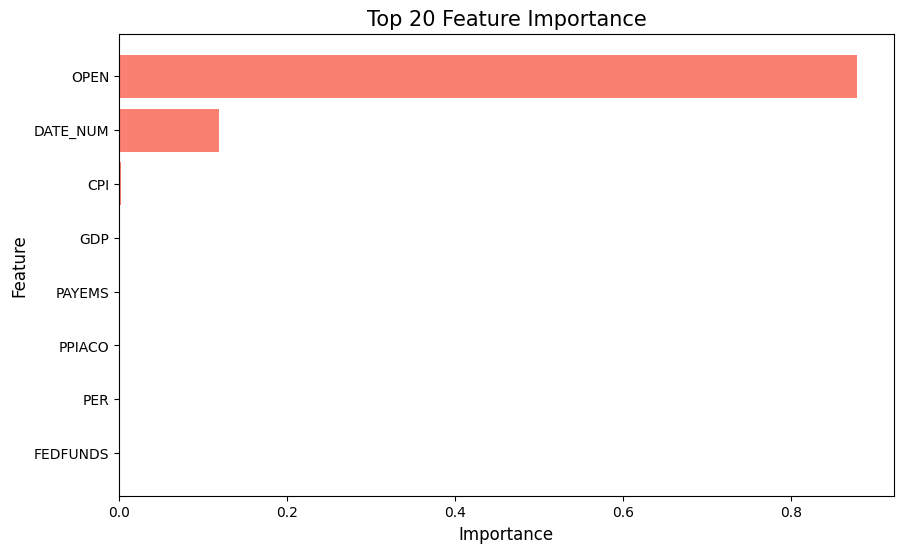

In [ ]:
import matplotlib.pyplot as plt

# Get the top 20 features
top_20_features = feature_imp.nlargest(20, 'Importance')

# Bar plot
plt.figure(figsize=(10, 6), dpi=100)
plt.barh(top_20_features['Feature'], top_20_features['Importance'], color='salmon')

plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 20 Feature Importance", fontsize=15)
plt.gca().invert_yaxis()  # Invert y axis to have the highest importance on top
plt.show()